# Applicability domain analysis

This section evaluates the reliability of model predictions using multiple applicability domain (AD) methods:
- **Leverage**: Measures influence of each sample on model predictions
- **Mahalanobis distance**: Multivariate distance from training data center
- **kNN distance**: Distance to nearest neighbors in training data
- **PCA T² statistic**: Distance in principal component space

AD analysis helps identify test samples where predictions may be unreliable due to being outside the domain of the training data. Visualizations and summary statistics are provided for each method.

## import necessary libraries

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import mahalanobis

import lightning as pl
import torch

from chemprop import data, featurizers, utils
from chemprop.models.utils import load_model

In [3]:
# reducing verbosity
import logging
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("torch").setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

In [4]:
RANDOM_SEED = 42

# Set seed for reproducibility
pl.seed_everything(RANDOM_SEED, workers=True)

Seed set to 42


42

Setting up local imports of custom python functions

In [5]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor


In [6]:
figs_dir = PROJECT_ROOT / "figs" 

ensemble_dir = PROJECT_ROOT / "models" / "ensemble_without_descriptors"

results_dir = PROJECT_ROOT / "data" / "processed" / "applicability_domain"

In [7]:
results_dir.mkdir(exist_ok=True, parents=True)
print(f"Results will be saved to: {results_dir}")

Results will be saved to: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/data/processed/applicability_domain


# Load models and datasets

In [8]:
# Data columns
smiles_column = 'SMILES_clean'
target_column = ['logTg']

In [9]:
# Load training data
df_train = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "training_data.csv")

all_smis = df_train.loc[:, smiles_column].values
all_ys = df_train.loc[:, target_column].values.flatten()  # Shape: (N,)

print(f"\nTraining data: {len(all_smis)} samples")
print(f"Training targets shape: {all_ys.shape}")


Training data: 683 samples
Training targets shape: (683,)


In [10]:
# create list of molecule objects from SMILES strings
all_mols = [
    utils.make_mol(smi, keep_h=False, add_h=False) for smi in all_smis
]

In [11]:
# Load independent test data
df_test = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "test_data.csv")

test_smis = df_test.loc[:, smiles_column].values
test_ys = df_test.loc[:, target_column].values.flatten()

print(f"\nTest data: {len(test_smis)} samples")
print(f"Test targets shape: {test_ys.shape}")


Test data: 219 samples
Test targets shape: (219,)


In [12]:
# Prepare input data
test_mols = [
    utils.make_mol(smi, keep_h=False, add_h=False) for smi in test_smis
]

In [13]:
# Load K-fold train/val split indices from metadata
with open(PROJECT_ROOT / "models" / "train_data_split_indexes.pkl", "rb") as f:
    train_idxs_dict = pickle.load(f)

with open(PROJECT_ROOT / "models" / "validation_data_split_indexes.pkl", "rb") as f:
    val_idxs_dict = pickle.load(f)

In [14]:
train_mols_kfold_dict = {}
train_ys_kfold_dict = {}
val_mols_kfold_dict = {}
val_ys_kfold_dict = {}

for fold_ in train_idxs_dict.keys():
    print("Fold:", fold_ + 1)
    print("Total training samples:", len(train_idxs_dict[fold_]))
    print("Total validation samples:", len(val_idxs_dict[fold_]))
    train_mols_kfold_dict[fold_] = [all_mols[i] for i in train_idxs_dict[fold_]]
    train_ys_kfold_dict[fold_] = all_ys[train_idxs_dict[fold_]]
    val_mols_kfold_dict[fold_] = [all_mols[i] for i in val_idxs_dict[fold_]]
    val_ys_kfold_dict[fold_] = all_ys[val_idxs_dict[fold_]]

Fold: 1
Total training samples: 614
Total validation samples: 69
Fold: 2
Total training samples: 614
Total validation samples: 69
Fold: 3
Total training samples: 614
Total validation samples: 69
Fold: 4
Total training samples: 615
Total validation samples: 68
Fold: 5
Total training samples: 615
Total validation samples: 68
Fold: 6
Total training samples: 615
Total validation samples: 68
Fold: 7
Total training samples: 615
Total validation samples: 68
Fold: 8
Total training samples: 615
Total validation samples: 68
Fold: 9
Total training samples: 615
Total validation samples: 68
Fold: 10
Total training samples: 615
Total validation samples: 68


In [15]:
# Load WITH descriptors ensemble
print("Loading WITHOUT descriptors ensemble...")

models_without_desc = {}

for fold_ in train_idxs_dict.keys():
    models_without_desc[fold_] = []
    # Find all best_model.ckpt files in the k-fold/seed structure
    model_ckpt_paths = sorted(ensemble_dir.glob(f"fold_{fold_+1}/seed_*/best_model.ckpt"))

    for ckpt_path in tqdm(model_ckpt_paths, desc=f"Loading WITH descriptors fold {fold_}"):
        model = load_model(ckpt_path)
        models_without_desc[fold_].append(model)

print(f"Loaded {sum(len(models) for models in models_without_desc.values())} models WITH descriptors")

Loading WITHOUT descriptors ensemble...


Loading WITH descriptors fold 9: 100%|██████████| 100/100 [00:00<00:00, 158.09it/s]

Loaded 1000 models WITH descriptors


# Extract D-MPNN embeddings

In [16]:
def prep_data_loader(
    mols_,
    num_workers=0,
):
    """
    Prepare a data loader for the given SMILES strings and optional features.
    Parameters:
        smis_ (list of str): List of SMILES strings representing molecules.
        num_workers (int): 

    Returns:
        DataLoader: A PyTorch DataLoader for the dataset.
    """
    data_ = [data.MoleculeDatapoint(mol) for mol in mols_]
    
    # initialize featurizer and dataset
    featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
    
    dset_ = data.MoleculeDataset(data_, featurizer)
    
    # create data loader
    return data.build_dataloader(
        dset_,
        batch_size=len(mols_),
        num_workers=num_workers,
        shuffle=False
    )

In [17]:
def get_MPNN_encodings(
    model_ensemble_,
    data_loader_
):
    """
    """
    all_encodings_list = []
    for model_0 in model_ensemble_:
        with torch.no_grad():
            encodings = [
                model_0.encoding(batch.bmg, i=1) for batch in data_loader_
            ]

    encodings = torch.cat(encodings, 0)
    all_encodings_list.append(encodings)

    all_encodings_tensor = torch.stack(all_encodings_list, dim=0)
    return all_encodings_tensor

In [18]:
def tranform_data_to_mean_embeddings(
    mols_,
    models_
):
    """
    Transform data to mean embeddings

    Parameters:
        mols_: list of molecule objects
        models_: list of models

    Returns:
        h_mean_np: numpy array
            Mean embeddings of the data
    """
    data_loader_ = prep_data_loader(mols_=mols_)
    data_encodings = get_MPNN_encodings(
        model_ensemble_=models_,
        data_loader_=data_loader_
    )
    h_mean = data_encodings.mean(dim=0)
    
    print("Mean embeddings array shape", h_mean.shape)

    # If mean_encodings is a torch tensor, convert to numpy
    h_mean_np = h_mean.cpu().numpy()  # shape: (683, 300)
    
    return h_mean_np

In [19]:

# initialize dictionaries to store results
mean_train_embeddings = {}
mean_val_embeddings = {}
mean_test_embeddings = {}
# loop over folds
for fold_ in train_idxs_dict.keys():
    print("Fold:", fold_ + 1)
    # initialize scaler
    scaler = StandardScaler()

    # extract mean embeddings for train, val and test data
    train_emb = tranform_data_to_mean_embeddings(
        mols_=train_mols_kfold_dict[fold_],
        models_=models_without_desc[fold_]
    )
    val_emb = tranform_data_to_mean_embeddings(
        mols_=val_mols_kfold_dict[fold_],
        models_=models_without_desc[fold_]
    )
    test_emb = tranform_data_to_mean_embeddings(
        mols_=test_mols,
        models_=models_without_desc[fold_]
    )
    # fit scaler on train data and transform train, val and test data
    mean_train_embeddings[fold_] = scaler.fit_transform(train_emb)
    mean_val_embeddings[fold_] = scaler.transform(val_emb)
    mean_test_embeddings[fold_] = scaler.transform(test_emb)

Fold: 1
Mean embeddings array shape torch.Size([614, 300])
Mean embeddings array shape torch.Size([69, 300])
Mean embeddings array shape torch.Size([219, 300])
Fold: 2
Mean embeddings array shape torch.Size([614, 300])
Mean embeddings array shape torch.Size([69, 300])
Mean embeddings array shape torch.Size([219, 300])
Fold: 3
Mean embeddings array shape torch.Size([614, 300])
Mean embeddings array shape torch.Size([69, 300])
Mean embeddings array shape torch.Size([219, 300])
Fold: 4
Mean embeddings array shape torch.Size([615, 300])
Mean embeddings array shape torch.Size([68, 300])
Mean embeddings array shape torch.Size([219, 300])
Fold: 5
Mean embeddings array shape torch.Size([615, 300])
Mean embeddings array shape torch.Size([68, 300])
Mean embeddings array shape torch.Size([219, 300])
Fold: 6
Mean embeddings array shape torch.Size([615, 300])
Mean embeddings array shape torch.Size([68, 300])
Mean embeddings array shape torch.Size([219, 300])
Fold: 7
Mean embeddings array shape torc

# Calculate AD metrics

In [125]:
# add code for leverage values
def calculate_leverage_values(
    X_train,
    X_test,
    reg_param = 5e-1
):
    """
    Calculate leverage values for test samples based on training data.
    """    
    # Add a column of ones to X_train for the intercept
    X_train_augmented = np.hstack([np.ones((X_train.shape[0], 1)), X_train])

    # Calculate the hat matrix
    XtX = X_train_augmented.T @ X_train_augmented + reg_param * np.eye(X_train_augmented.shape[1])
    hat_matrix = X_train_augmented @ np.linalg.inv(XtX) @ X_train_augmented.T

    # Calculate leverage values for training data (diagonal of hat matrix)
    leverage_train = np.diag(hat_matrix)

    # Add a column of ones to X_test for the intercept
    X_test_augmented = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

    # Calculate leverage values for test data
    leverage_test = np.sum(X_test_augmented @ np.linalg.inv(XtX) * X_test_augmented, axis=1)

    return leverage_train, leverage_test

In [126]:
def calculate_mahalanobis_ad(
    X_train,
    X_test,
    reg_param = 5e-2
):
    """
    Calculate Mahalanobis distance with robust covariance estimation

    Parameters:
        X_train: numpy array
            Training data
        X_test: numpy array
            Test data
        reg_param: float
            Regularization parameter

    Returns:
        mahal_train: numpy array
            Mahalanobis distances for training data
        mahal_test: numpy array
            Mahalanobis distances for test data
    """
    mean_vec = np.mean(X_train, axis=0)
    cov_matrix = np.cov(X_train, rowvar=False)
    cov_matrix += reg_param * np.eye(cov_matrix.shape[0])
    try:
        inv_cov_matrix = np.linalg.inv(cov_matrix)
        mahal_train = [mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_train]
        mahal_test = [mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_test]
        return np.array(mahal_train), np.array(mahal_test)
    except np.linalg.LinAlgError:
        print("Warning: Singular covariance matrix in Mahalanobis calculation")
        return None, None

In [127]:
def calculate_knn_ad(
    X_train: np.ndarray,
    X_test: np.ndarray,
    k_values: list[int] = [3, 5, 10]
) -> dict:
    """
    Calculate kNN distances with multiple k values
    
    Parameters:
        X_train: numpy array
            Training data
        X_test: numpy array
            Test data
        k_values: list
            List of k values to calculate kNN distances for

    Returns:
        knn_results: dict
            Dictionary containing kNN distances for each k value
            Keys: k values
            Values: dicts with 'train_distances' and 'test_distances'
    """
    knn_results = {}
    for k in k_values:
        if k < len(X_train):
            print(f"Calculating kNN distance for k={k}")
            knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
            print("Fitting kNN model")
            knn.fit(X_train)
            print("Calculating train distances")
            train_distances, _ = knn.kneighbors(X_train)
            print("Calculating train mean distance")
            train_mean_dist = train_distances[:, 1:].mean(axis=1)
            print("Calculating test distances")
            test_distances, _ = knn.kneighbors(X_test)
            test_mean_dist = test_distances.mean(axis=1)
            
            knn_results[k] = {
                'train_distances': train_mean_dist,
                'test_distances': test_mean_dist,
            }

    return knn_results

In [128]:
def calculate_pca_ad(
    X_train: np.ndarray,
    X_test: np.ndarray,
    n_components: int = 10,
    variance_threshold: float = 0.95
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, PCA]:
    """
    Calculate PCA-based applicability domain

    Parameters:
        X_train: numpy array
            Training data
        X_test: numpy array
            Test data
        n_components: int
            Number of principal components to use
        variance_threshold: float
            Variance threshold for PCA

    Returns:
        X_train_pca: numpy array
    """

    pca = PCA(n_components=n_components)
    pca.fit(X_train)
    
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumvar >= variance_threshold) + 1
    
    pca_reduced = PCA(n_components=n_components)
    
    X_train_pca = pca_reduced.fit_transform(X_train)
    X_test_pca = pca_reduced.transform(X_test)
    mean_pca = np.mean(X_train_pca, axis=0)
    
    cov_pca = np.cov(X_train_pca, rowvar=False)
    
    if n_components == 1:
        inv_cov_pca = 1.0 / cov_pca
        t2_train = [(x - mean_pca)**2 * inv_cov_pca for x in X_train_pca.flatten()]
        t2_test = [(x - mean_pca)**2 * inv_cov_pca for x in X_test_pca.flatten()]
    else:
        inv_cov_pca = np.linalg.inv(cov_pca + 1e-6 * np.eye(cov_pca.shape[0]))
        t2_train = [mahalanobis(x, mean_pca, inv_cov_pca)**2 for x in X_train_pca]
        t2_test = [mahalanobis(x, mean_pca, inv_cov_pca)**2 for x in X_test_pca]
    
    return X_train_pca, X_test_pca, np.array(t2_train), np.array(t2_test), pca_reduced

In [129]:
# initialize dictionaries to store results
leverage_train_val = {}
leverage_val = {}
leverage_train_test = {}
leverage_test = {}
mahal_train_val = {}
mahal_val = {}
mahal_train_test = {}
mahal_test = {}
knn_results_val = {}
knn_results_test = {}
pca_results_val = {}
pca_results_test = {}
# loop over folds
for fold_ in train_idxs_dict.keys():
    print("Fold:", fold_ + 1)
    # validation data leverage values
    leverage_train_val[fold_], leverage_val[fold_] = calculate_leverage_values(
        X_train=mean_train_embeddings[fold_],
        X_test=mean_val_embeddings[fold_]
    )
    # validation data mahalanobis distance
    mahal_train_val[fold_], mahal_val[fold_] = calculate_mahalanobis_ad(
        X_train=mean_train_embeddings[fold_],
        X_test=mean_val_embeddings[fold_]
    )
    # knn distance for validation data
    knn_results_val[fold_] = calculate_knn_ad(
        X_train=mean_train_embeddings[fold_],
        X_test=mean_val_embeddings[fold_]
    )
    # validation data PCA T² statistic
    pca_results_val[fold_] = calculate_pca_ad(
        X_train=mean_train_embeddings[fold_],
        X_test=mean_val_embeddings[fold_]
    )
    
    # test data leverage values
    leverage_train_test[fold_], leverage_test[fold_] = calculate_leverage_values(
        X_train=mean_train_embeddings[fold_],
        X_test=mean_test_embeddings[fold_]
    )
    # test data mahalanobis distance
    mahal_train_test[fold_], mahal_test[fold_] = calculate_mahalanobis_ad(
        X_train=mean_train_embeddings[fold_],
        X_test=mean_test_embeddings[fold_]
    )
    # test data kNN distance
    knn_results_test[fold_] = calculate_knn_ad(
        X_train=mean_train_embeddings[fold_],
        X_test=mean_test_embeddings[fold_]
    )
    # test data PCA T² statistic
    pca_results_test[fold_] = calculate_pca_ad(
        X_train=mean_train_embeddings[fold_],
        X_test=mean_test_embeddings[fold_]
    )

Fold: 1
Calculating kNN distance for k=3
Fitting kNN model
Calculating train distances
Calculating train mean distance
Calculating test distances
Calculating kNN distance for k=5
Fitting kNN model
Calculating train distances
Calculating train mean distance
Calculating test distances
Calculating kNN distance for k=10
Fitting kNN model
Calculating train distances
Calculating train mean distance
Calculating test distances
Calculating kNN distance for k=3
Fitting kNN model
Calculating train distances
Calculating train mean distance
Calculating test distances
Calculating kNN distance for k=5
Fitting kNN model
Calculating train distances
Calculating train mean distance
Calculating test distances
Calculating kNN distance for k=10
Fitting kNN model
Calculating train distances
Calculating train mean distance
Calculating test distances
Fold: 2
Calculating kNN distance for k=3
Fitting kNN model
Calculating train distances
Calculating train mean distance
Calculating test distances
Calculating kNN 

# Visualize AD metrics

In [130]:
def find_leverage_threshold(
    leverage_train,
    metric_dimensions,
    threshold_multiplier=3
):
    """
    """
    # find outliers based on leverage values
    print(f"Metric dimensions: {metric_dimensions}")
    print(f"Length of leverage train: {len(leverage_train)}")
    leverage_threshold = threshold_multiplier *(metric_dimensions+1)/len(leverage_train)
    
    print("Leverage threshold: {:.3f}".format(leverage_threshold))

    return leverage_threshold

In [131]:
def find_percentile_threshold(
    metric_train,
    percentile=0.95
):
    """
    """
    return np.percentile(metric_train, percentile)

In [132]:
def find_outliers(
    metric_test,
    metric_threshold,
    metric_name
):
    """
    """
    print(f"Max value of {metric_name}: {metric_test.max():.3f}")

    outliers = np.where(metric_test > metric_threshold)[0]
    within_metric_threshold = np.where(metric_test <= metric_threshold)[0]
    
    print(f'{metric_name} data')
    print("Number of outliers: ", len(outliers))
    print("Number within leverage threshold: ", len(within_metric_threshold))

    return outliers, within_metric_threshold

In [171]:
def plot_AD_distribution(
    metric_train,
    train_bin_num,
    metric_test,
    test_bin_num,
    metric_threshold,
    metric_name,
    label_='Test'
):
    """
    Compute histogram counts and plot probability distribution

    Parameters:
        metric_train: numpy array
        train_bin_num: int
        metric_test: numpy array
        test_bin_num: int
        metric_threshold: float
        metric_name: str
    """
    counts_train, bins_train = np.histogram(metric_train, bins=train_bin_num)
    counts_test, bins_test = np.histogram(metric_test, bins=test_bin_num)

    # Normalize so max height is 1
    probs_train = counts_train / counts_train.sum()
    probs_test = counts_test / counts_test.sum()

    plt.figure(figsize=(6, 4))
    plt.bar(
        bins_train[:-1],
        probs_train,
        width=np.diff(bins_train),
        alpha=0.5,
        label='Train',
        align='edge',
        color='black',
        edgecolor='black',  # Darker outline
        linewidth=2
    )
    plt.bar(
        bins_test[:-1],
        probs_test,
        width=np.diff(bins_test),
        alpha=0.5,
        label=label_,
        align='edge',
        color='gray',
        edgecolor='black',  # Darker outline
        linewidth=2
    )
    plt.axvline(
        metric_threshold,
        color='red',
        linestyle='--',
        label=f'{metric_name} Threshold'
    )
    plt.xlabel(metric_name, fontsize=12)
    plt.ylabel('Probability distribution', fontsize=12)
    plt.title(f'{metric_name} Probability Distribution', fontsize=12)
    plt.legend(fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

## Validation Data

### Leverage values

Metric dimensions: 300
Length of leverage train: 614
Leverage threshold: 1.471
Leverage threshold for fold 1: 1.4707
Max value of Leverage: 10.987
Leverage data
Number of outliers:  9
Number within leverage threshold:  60
Leverage values outliers for fold 1: 9
Leverage values within threshold for fold 1: 60
Metric dimensions: 300
Length of leverage train: 614
Leverage threshold: 1.471
Leverage threshold for fold 2: 1.4707
Max value of Leverage: 4.453
Leverage data
Number of outliers:  14
Number within leverage threshold:  55
Leverage values outliers for fold 2: 14
Leverage values within threshold for fold 2: 55
Metric dimensions: 300
Length of leverage train: 614
Leverage threshold: 1.471
Leverage threshold for fold 3: 1.4707
Max value of Leverage: 8.611
Leverage data
Number of outliers:  10
Number within leverage threshold:  59
Leverage values outliers for fold 3: 10
Leverage values within threshold for fold 3: 59
Metric dimensions: 300
Length of leverage train: 615
Leverage threshold

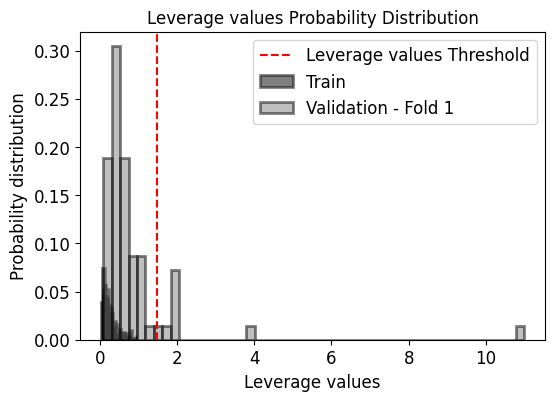

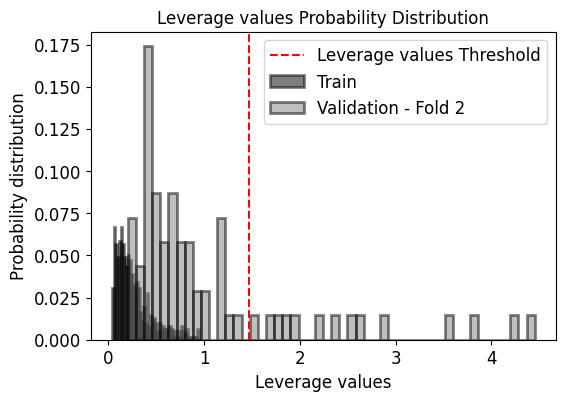

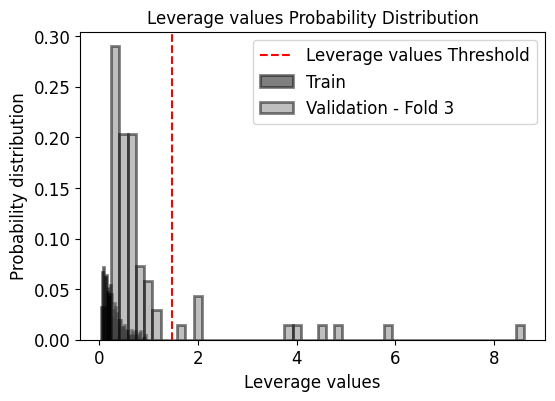

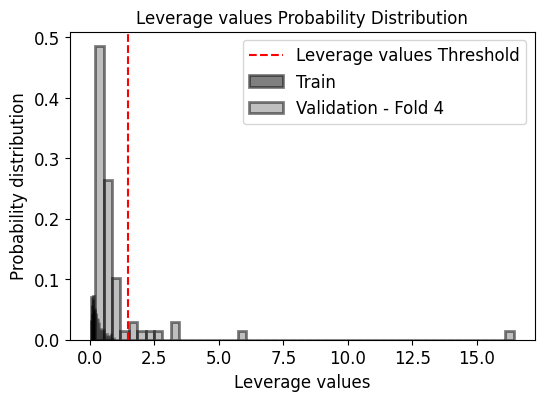

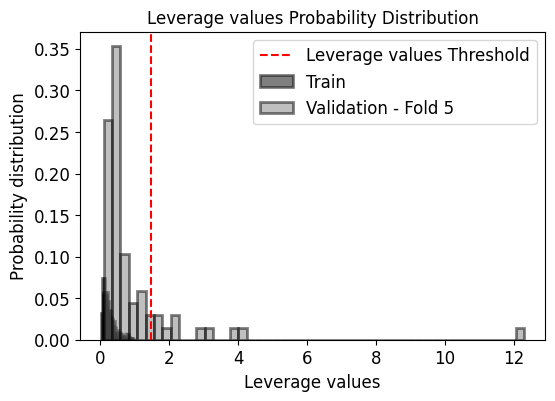

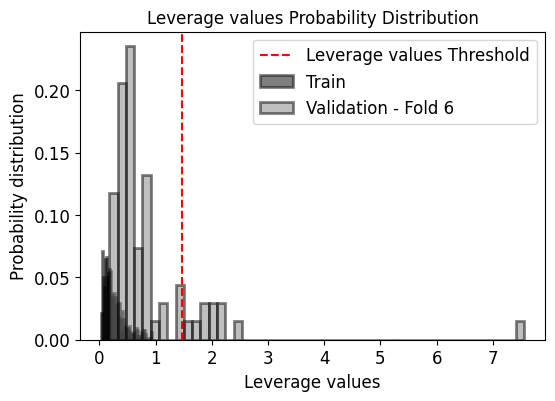

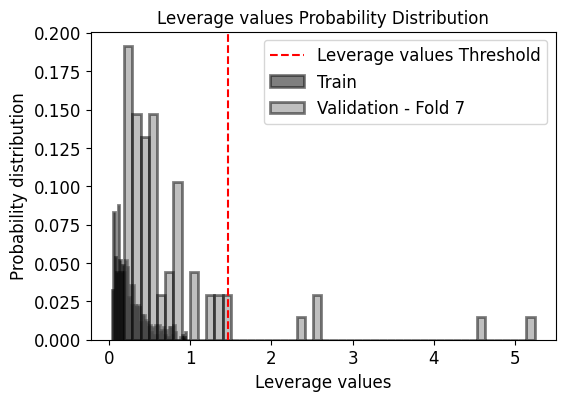

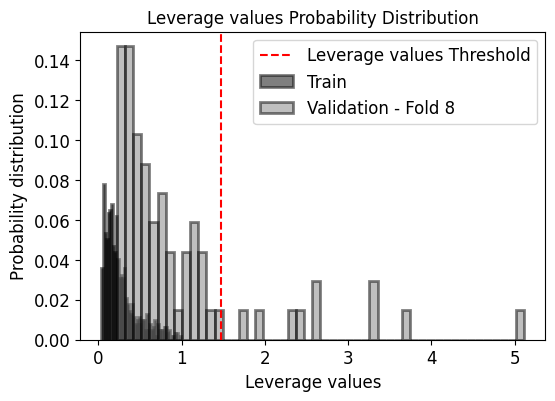

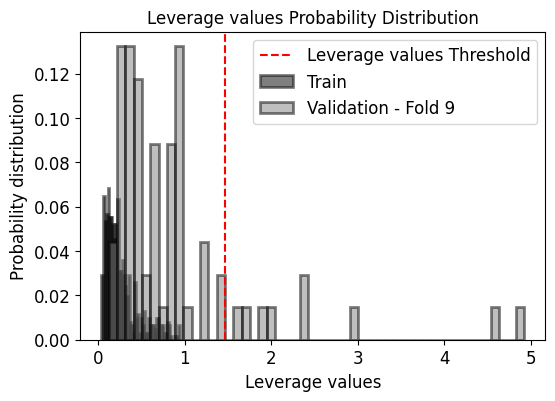

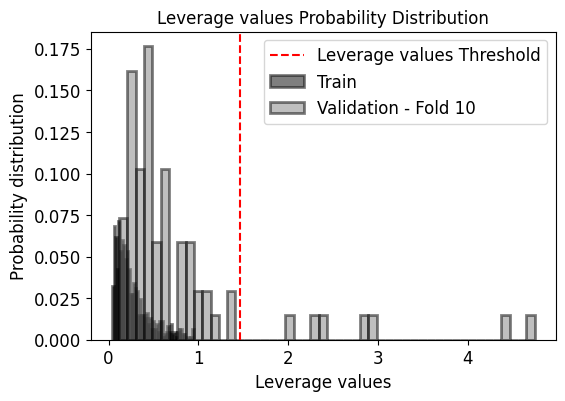

In [172]:
# leverage values
leverage_threshold_val = {}
leverage_outliers_val = {}
leverage_within_threshold_val = {}
for fold_ in train_idxs_dict.keys():
    leverage_threshold_val[fold_] = find_leverage_threshold(
        leverage_train=leverage_train_val[fold_],
        metric_dimensions=mean_train_embeddings[fold_].shape[1],
    )
    print(f"Leverage threshold for fold {fold_ + 1}: {leverage_threshold_val[fold_]:.4f}")
    leverage_outliers_val[fold_], leverage_within_threshold_val[fold_] = find_outliers(
        metric_test=leverage_val[fold_],
        metric_threshold=leverage_threshold_val[fold_],
        metric_name="Leverage"
    )
    print(f"Leverage values outliers for fold {fold_ + 1}: {len(leverage_outliers_val[fold_])}")
    print(f"Leverage values within threshold for fold {fold_ + 1}: {len(leverage_within_threshold_val[fold_])}")
    
for fold_ in train_idxs_dict.keys():
    plot_AD_distribution(
        metric_train=leverage_train_val[fold_],
        train_bin_num=50,
        metric_test=leverage_val[fold_],
        test_bin_num=50,
        metric_threshold=leverage_threshold_val[fold_],
        metric_name="Leverage values",
        label_=f'Validation - Fold {fold_ + 1}'
    )

### Mahalanobis distance

Mahalanobis threshold for fold 1: 15.4035
Max value of Mahalanobis distance: 38.949
Mahalanobis distance data
Number of outliers:  5
Number within leverage threshold:  64
Mahalanobis distance outliers for fold 1: 5
Mahalanobis distance within threshold for fold 1: 64
Mahalanobis threshold for fold 2: 14.9951
Max value of Mahalanobis distance: 23.580
Mahalanobis distance data
Number of outliers:  10
Number within leverage threshold:  59
Mahalanobis distance outliers for fold 2: 10
Mahalanobis distance within threshold for fold 2: 59
Mahalanobis threshold for fold 3: 14.7918
Max value of Mahalanobis distance: 32.222
Mahalanobis distance data
Number of outliers:  8
Number within leverage threshold:  61
Mahalanobis distance outliers for fold 3: 8
Mahalanobis distance within threshold for fold 3: 61
Mahalanobis threshold for fold 4: 15.1281
Max value of Mahalanobis distance: 39.262
Mahalanobis distance data
Number of outliers:  9
Number within leverage threshold:  59
Mahalanobis distance ou

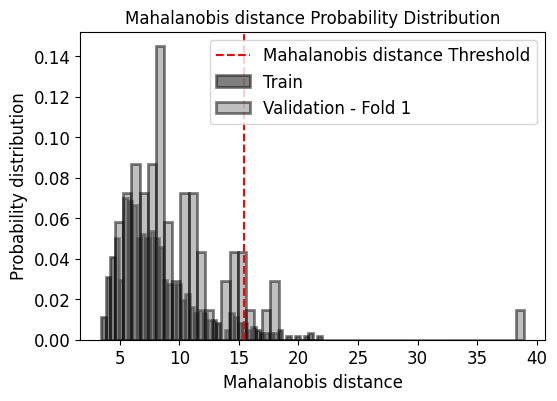

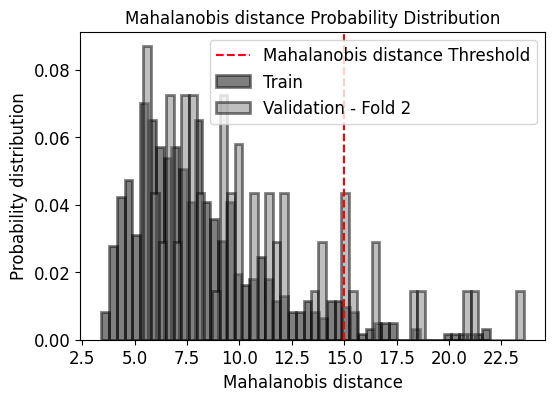

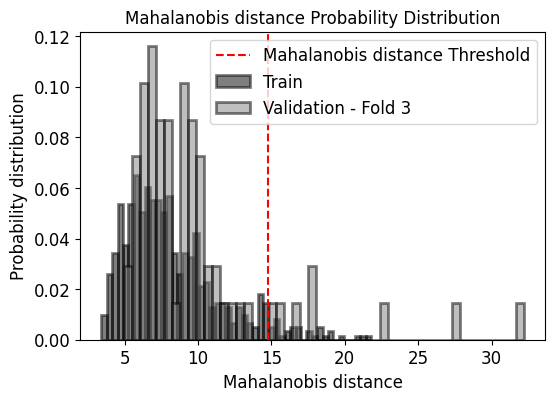

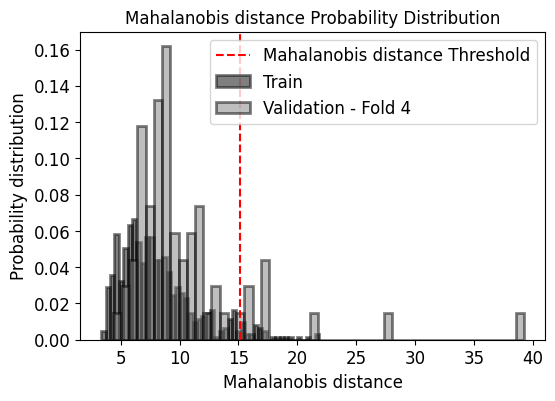

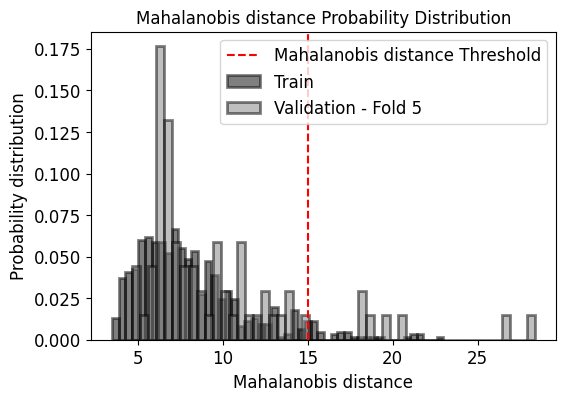

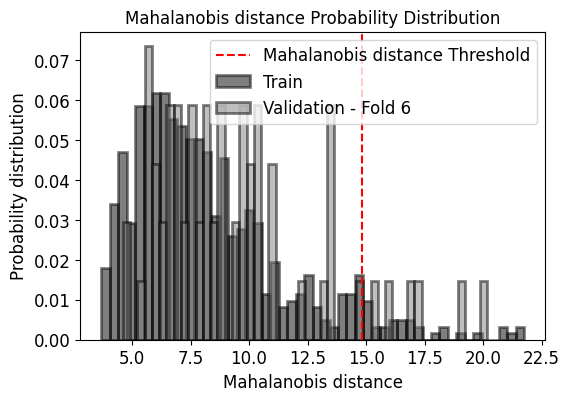

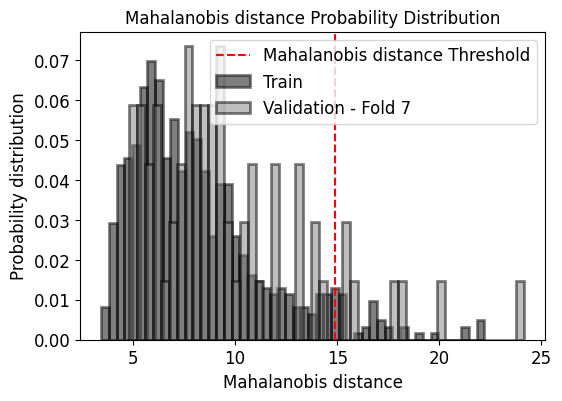

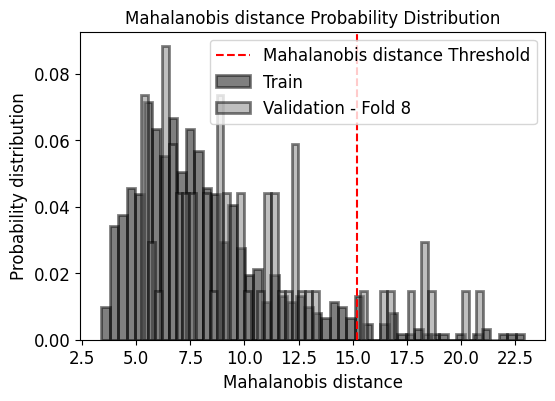

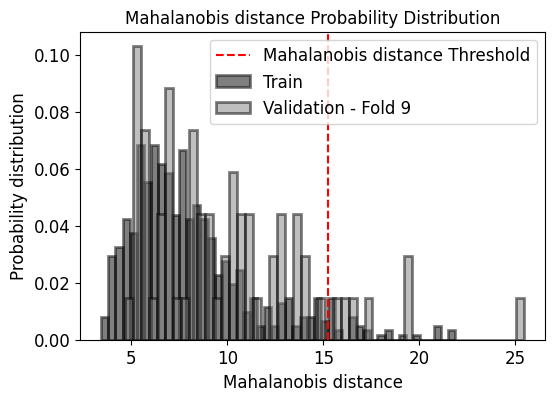

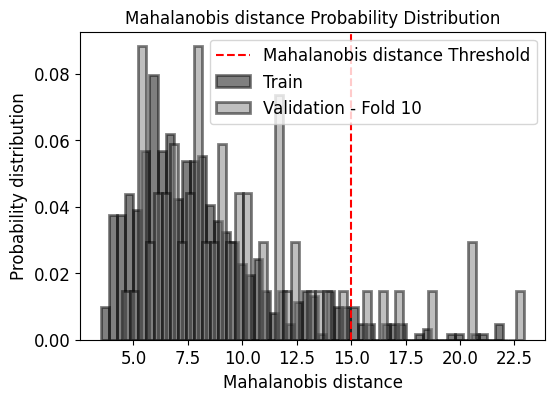

In [173]:
# mahalanobis distance
mahal_threshold_val = {}
mahal_outliers_val = {}
mahal_within_threshold_val = {}
for fold_ in train_idxs_dict.keys():
    mahal_threshold_val[fold_] = find_percentile_threshold(
        metric_train=mahal_train_val[fold_],
        percentile=95
    )
    print(f"Mahalanobis threshold for fold {fold_ + 1}: {mahal_threshold_val[fold_]:.4f}")
    mahal_outliers_val[fold_], mahal_within_threshold_val[fold_] = find_outliers(
        metric_test=mahal_val[fold_],
        metric_threshold=mahal_threshold_val[fold_],
        metric_name="Mahalanobis distance"
    )
    print(f"Mahalanobis distance outliers for fold {fold_ + 1}: {len(mahal_outliers_val[fold_])}")
    print(f"Mahalanobis distance within threshold for fold {fold_ + 1}: {len(mahal_within_threshold_val[fold_])}")
    
for fold_ in train_idxs_dict.keys():
    plot_AD_distribution(
        metric_train=mahal_train_val[fold_],
        train_bin_num=50,
        metric_test=mahal_val[fold_],
        test_bin_num=50,
        metric_threshold=mahal_threshold_val[fold_],
        metric_name="Mahalanobis distance",
        label_=f'Validation - Fold {fold_ + 1}'
    )

### KNN distance

In [174]:
knn_results_val[0].keys()

dict_keys([3, 5, 10])

KNN threshold for fold 1: 17.0041
Max value of KNN distance: 24.332
KNN distance data
Number of outliers:  1
Number within leverage threshold:  68
KNN distance outliers for fold 1: 1
KNN distance within threshold for fold 1: 68
KNN threshold for fold 2: 16.1653
Max value of KNN distance: 22.522
KNN distance data
Number of outliers:  3
Number within leverage threshold:  66
KNN distance outliers for fold 2: 3
KNN distance within threshold for fold 2: 66
KNN threshold for fold 3: 15.7163
Max value of KNN distance: 27.786
KNN distance data
Number of outliers:  4
Number within leverage threshold:  65
KNN distance outliers for fold 3: 4
KNN distance within threshold for fold 3: 65
KNN threshold for fold 4: 16.2115
Max value of KNN distance: 25.715
KNN distance data
Number of outliers:  3
Number within leverage threshold:  65
KNN distance outliers for fold 4: 3
KNN distance within threshold for fold 4: 65
KNN threshold for fold 5: 16.4588
Max value of KNN distance: 21.217
KNN distance data
Nu

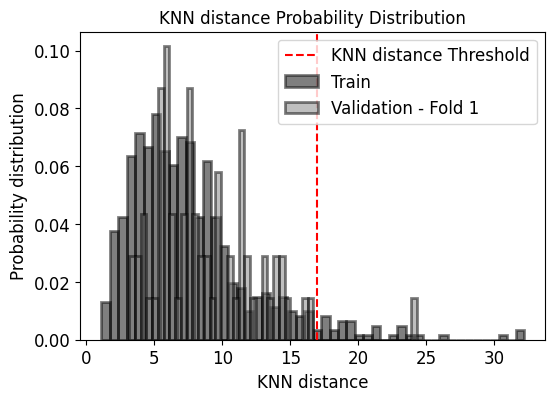

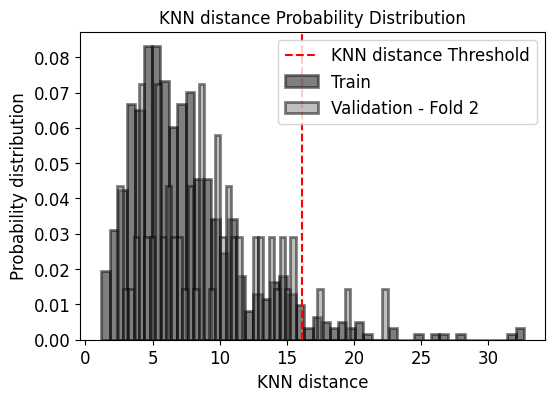

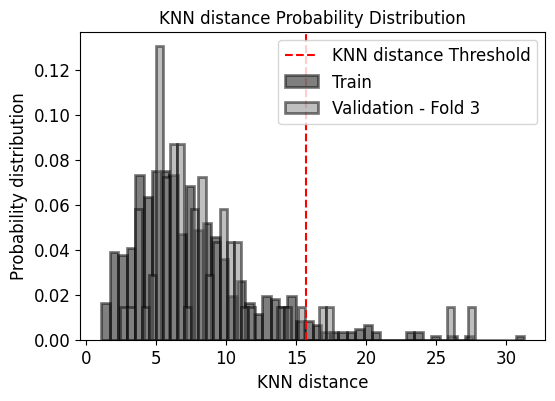

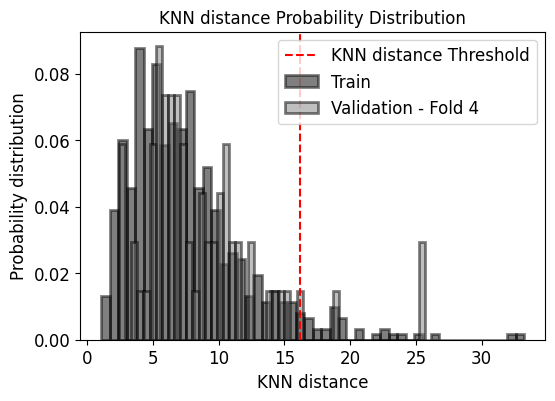

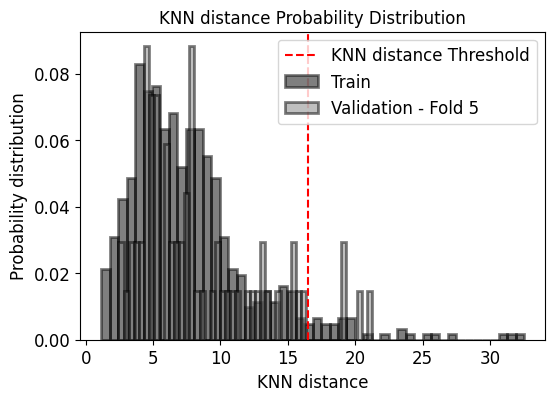

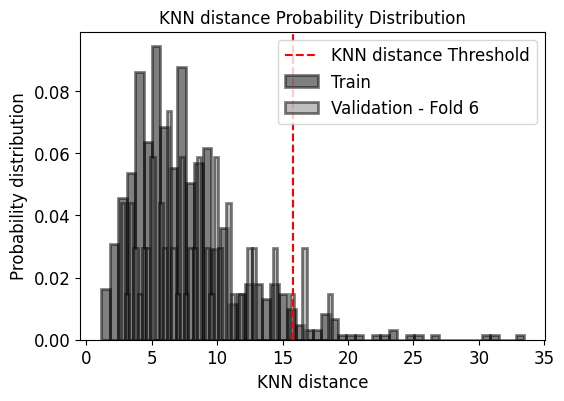

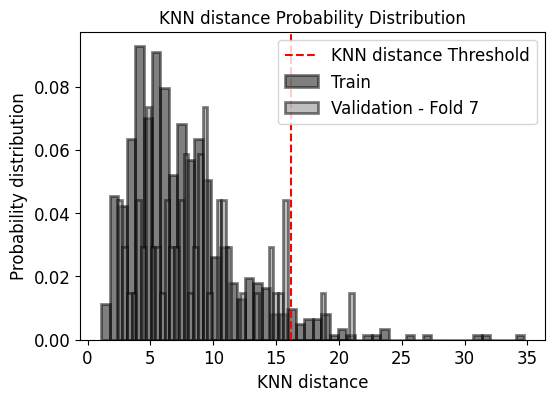

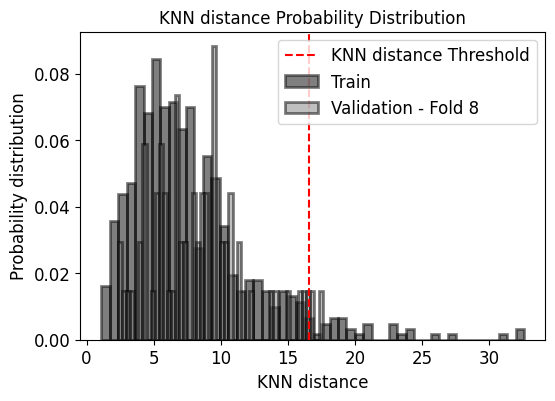

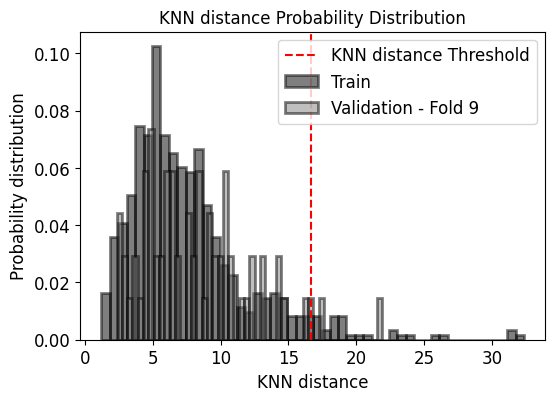

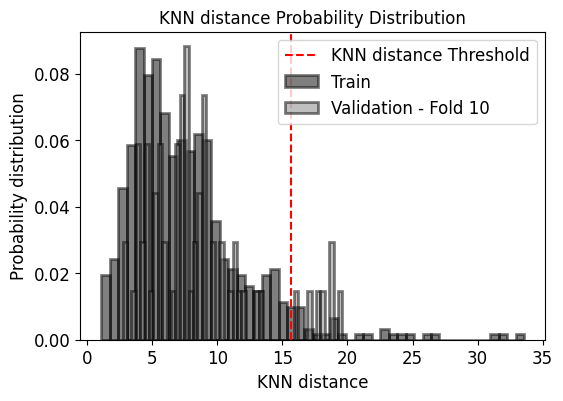

In [175]:
# knn distance
knn_threshold_val = {}
knn_outliers_val = {}
knn_within_threshold_val = {}
for fold_ in train_idxs_dict.keys():
    knn_threshold_val[fold_] = find_percentile_threshold(
        metric_train=knn_results_val[fold_][5]['train_distances'],
        percentile=95
    )
    print(f"KNN threshold for fold {fold_ + 1}: {knn_threshold_val[fold_]:.4f}")
    knn_outliers_val[fold_], knn_within_threshold_val[fold_] = find_outliers(
        metric_test=knn_results_val[fold_][5]['test_distances'],
        metric_threshold=knn_threshold_val[fold_],
        metric_name="KNN distance"
    )
    print(f"KNN distance outliers for fold {fold_ + 1}: {len(knn_outliers_val[fold_])}")
    print(f"KNN distance within threshold for fold {fold_ + 1}: {len(knn_within_threshold_val[fold_])}")
    
for fold_ in train_idxs_dict.keys():
    plot_AD_distribution(
        metric_train=knn_results_val[fold_][5]['train_distances'],
        train_bin_num=50,
        metric_test=knn_results_val[fold_][5]['test_distances'],
        test_bin_num=50,
        metric_threshold=knn_threshold_val[fold_],
        metric_name="KNN distance",
        label_=f'Validation - Fold {fold_ + 1}'
    )


### PCA - T2 statistics

PCA T² threshold for fold 1: 2.4583
Max value of PCA T²: 3.576
PCA T² data
Number of outliers:  5
Number within leverage threshold:  64
PCA T² outliers for fold 1: 5
PCA T² within threshold for fold 1: 64
PCA T² threshold for fold 2: 2.5140
Max value of PCA T²: 3.079
PCA T² data
Number of outliers:  2
Number within leverage threshold:  67
PCA T² outliers for fold 2: 2
PCA T² within threshold for fold 2: 67
PCA T² threshold for fold 3: 2.4558
Max value of PCA T²: 3.438
PCA T² data
Number of outliers:  4
Number within leverage threshold:  65
PCA T² outliers for fold 3: 4
PCA T² within threshold for fold 3: 65
PCA T² threshold for fold 4: 2.5160
Max value of PCA T²: 3.348
PCA T² data
Number of outliers:  4
Number within leverage threshold:  64
PCA T² outliers for fold 4: 4
PCA T² within threshold for fold 4: 64
PCA T² threshold for fold 5: 2.4821
Max value of PCA T²: 2.833
PCA T² data
Number of outliers:  5
Number within leverage threshold:  63
PCA T² outliers for fold 5: 5
PCA T² within 

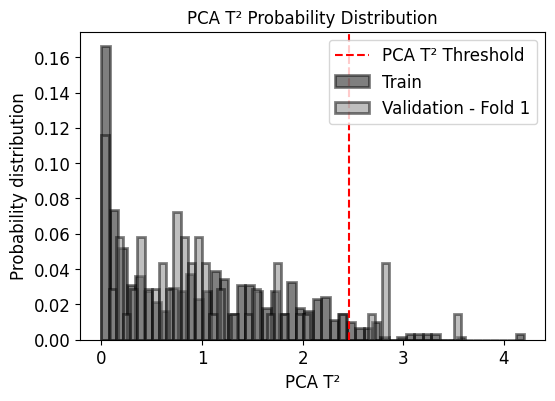

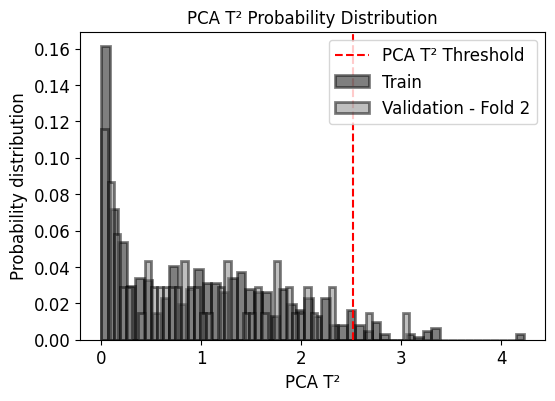

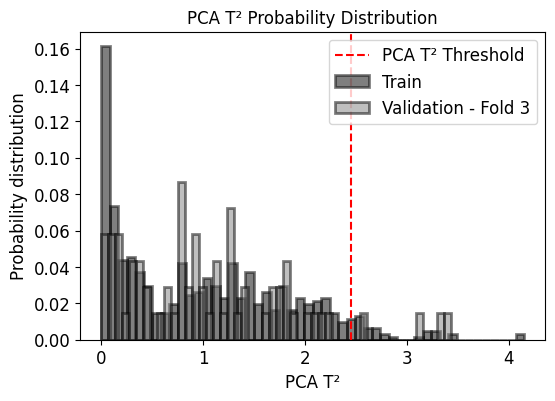

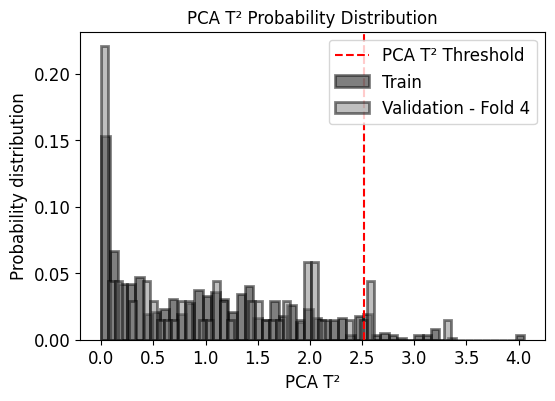

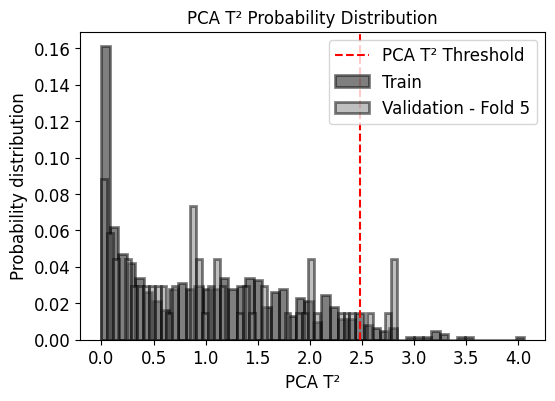

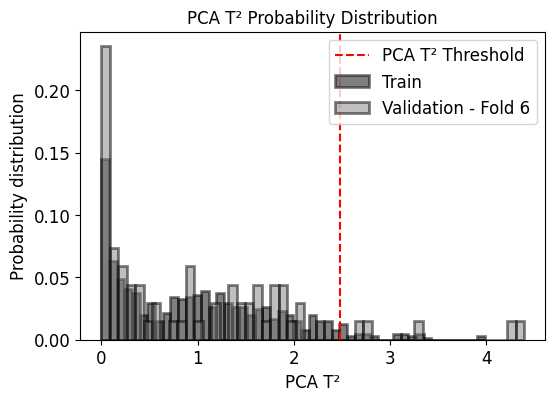

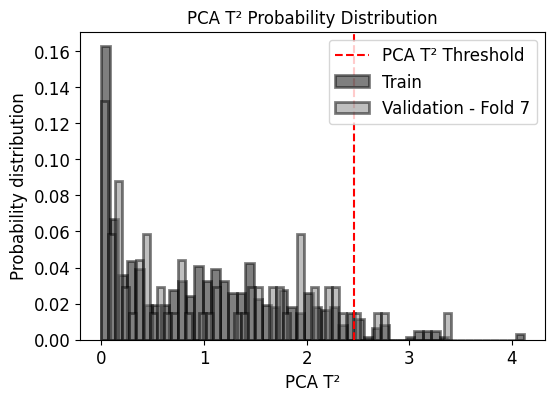

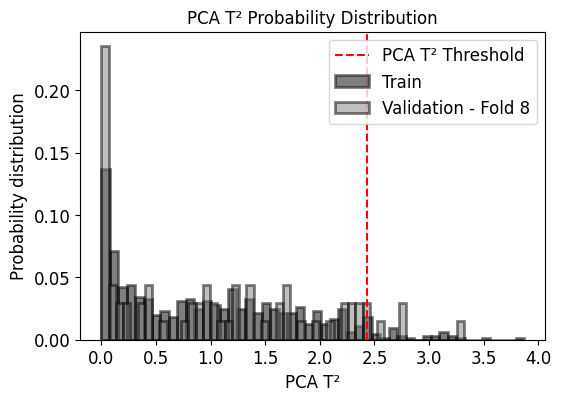

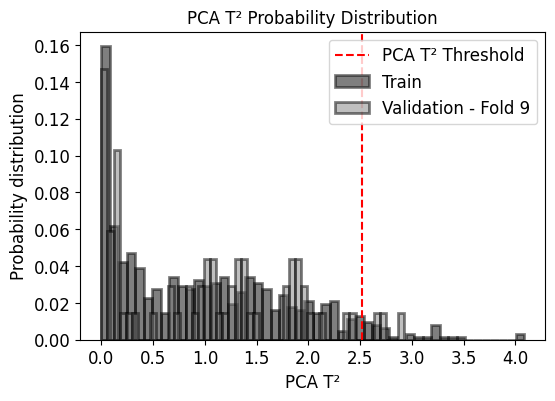

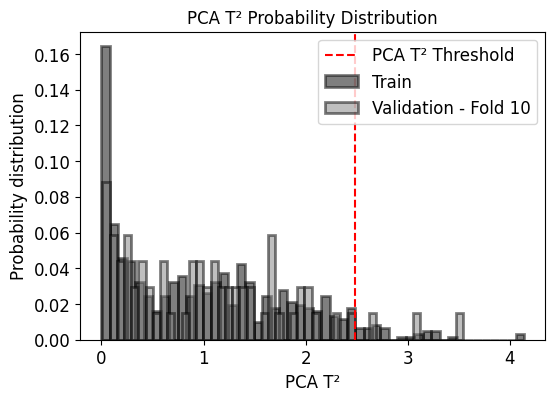

In [176]:
# PCA T2 statistics
pca_t2_threshold_val = {}
pca_t2_outliers_val = {}
pca_t2_within_threshold_val = {}
for fold_ in train_idxs_dict.keys():
    pca_t2_threshold_val[fold_] = find_percentile_threshold(
        metric_train=pca_results_val[fold_][2],
        percentile=95
    )
    print(f"PCA T² threshold for fold {fold_ + 1}: {pca_t2_threshold_val[fold_]:.4f}")
    pca_t2_outliers_val[fold_], pca_t2_within_threshold_val[fold_] = find_outliers(
        metric_test=pca_results_val[fold_][3],
        metric_threshold=pca_t2_threshold_val[fold_],
        metric_name="PCA T²"
    )
    print(f"PCA T² outliers for fold {fold_ + 1}: {len(pca_t2_outliers_val[fold_])}")
    print(f"PCA T² within threshold for fold {fold_ + 1}: {len(pca_t2_within_threshold_val[fold_])}")
    
for fold_ in train_idxs_dict.keys():
    plot_AD_distribution(
        metric_train=pca_results_val[fold_][2],
        train_bin_num=50,
        metric_test=pca_results_val[fold_][3],
        test_bin_num=50,
        metric_threshold=pca_t2_threshold_val[fold_],
        metric_name="PCA T²",
        label_=f'Validation - Fold {fold_ + 1}'
    )

### Saving results

In [178]:
# Collect validation SMILES and targets across all folds
val_smis_all = []
val_ys_all = []
val_fold_indices = []
leverage_val_all = []
mahal_val_all = []
knn_val_all = []
pca_t2_val_all = []
leverage_thresh_all = []
mahal_thresh_all = []
knn_thresh_all = []
pca_t2_thresh_all = []
k_value = 5

for fold_ in train_idxs_dict.keys():
    # get validation SMILES and targets for each fold
    val_smis_fold = [all_smis[i] for i in val_idxs_dict[fold_]]
    val_ys_fold = all_ys[val_idxs_dict[fold_]]
    n_val_samples = len(val_smis_fold)
    
    # collect SMILES and targets for all folds
    val_smis_all.extend(val_smis_fold)
    val_ys_all.extend(val_ys_fold)
    # collect fold indices for all folds
    val_fold_indices.extend([fold_] * n_val_samples)
    
    # get leverage values for each fold
    leverage_val_fold = leverage_val[fold_]
    # collect leverage values for all folds
    leverage_val_all.extend(leverage_val_fold) 
    
    # get mahalanobis values for each fold
    mahal_val_fold = mahal_val[fold_]
    # collect mahalanobis values for all folds
    mahal_val_all.extend(mahal_val_fold)
    
    # get KNN values for each fold
    knn_val_fold = knn_results_val[fold_][k_value]['test_distances']
    # collect KNN values for all folds
    knn_val_all.extend(knn_val_fold)
    
    # get PCA T2 values for each fold
    pca_t2_val_fold = pca_results_val[fold_][3]
    # collect PCA T2 values for all folds
    pca_t2_val_all.extend(pca_t2_val_fold)
    
    # get leverage thresholds for each fold (scalar, repeat for each sample)
    leverage_thresh_fold = leverage_threshold_val[fold_]
    # collect leverage thresholds for all folds (repeat for each sample in fold)
    leverage_thresh_all.extend([leverage_thresh_fold] * n_val_samples)
    
    # get mahalanobis thresholds for each fold (scalar, repeat for each sample)
    mahal_thresh_fold = mahal_threshold_val[fold_]
    # collect mahalanobis thresholds for all folds (repeat for each sample in fold)
    mahal_thresh_all.extend([mahal_thresh_fold] * n_val_samples)
    
    # get KNN thresholds for each fold (scalar, repeat for each sample)
    knn_thresh_fold = knn_threshold_val[fold_]
    # collect KNN thresholds for all folds (repeat for each sample in fold)
    knn_thresh_all.extend([knn_thresh_fold] * n_val_samples)
    
    # get PCA T2 thresholds for each fold (scalar, repeat for each sample)
    pca_t2_thresh_fold = pca_t2_threshold_val[fold_]
    # collect PCA T2 thresholds for all folds (repeat for each sample in fold)
    pca_t2_thresh_all.extend([pca_t2_thresh_fold] * n_val_samples)

# convert to numpy arrays
val_smis_all = np.array(val_smis_all)
val_ys_all = np.array(val_ys_all)
leverage_val_all = np.array(leverage_val_all)
mahal_val_all = np.array(mahal_val_all)
knn_val_all = np.array(knn_val_all)
pca_t2_val_all = np.array(pca_t2_val_all).flatten()
leverage_thresh_all = np.array(leverage_thresh_all)
mahal_thresh_all = np.array(mahal_thresh_all)
knn_thresh_all = np.array(knn_thresh_all)
pca_t2_thresh_all = np.array(pca_t2_thresh_all)

In [179]:
# Before creating DataFrame, check all lengths
print("Array length check:")
print(f"  val_smis_all: {len(val_smis_all)}")
print(f"  val_ys_all: {len(val_ys_all)} (shape: {val_ys_all.shape})")
print(f"  val_fold_indices: {len(val_fold_indices)}")
print(f"  leverage_val_all: {len(leverage_val_all)} (shape: {leverage_val_all.shape})")
print(f"  leverage_thresh_all: {len(leverage_thresh_all)} (shape: {leverage_thresh_all.shape})")
print(f"  mahal_val_all: {len(mahal_val_all)} (shape: {mahal_val_all.shape})")
print(f"  mahal_thresh_all: {len(mahal_thresh_all)} (shape: {mahal_thresh_all.shape})")
print(f"  knn_val_all: {len(knn_val_all)} (shape: {knn_val_all.shape})")
print(f"  knn_thresh_all: {len(knn_thresh_all)} (shape: {knn_thresh_all.shape})")
print(f"  pca_t2_val_all: {len(pca_t2_val_all)} (shape: {pca_t2_val_all.shape})")
print(f"  pca_t2_thresh_all: {len(pca_t2_thresh_all)} (shape: {pca_t2_thresh_all.shape})")

Array length check:
  val_smis_all: 683
  val_ys_all: 683 (shape: (683,))
  val_fold_indices: 683
  leverage_val_all: 683 (shape: (683,))
  leverage_thresh_all: 683 (shape: (683,))
  mahal_val_all: 683 (shape: (683,))
  mahal_thresh_all: 683 (shape: (683,))
  knn_val_all: 683 (shape: (683,))
  knn_thresh_all: 683 (shape: (683,))
  pca_t2_val_all: 683 (shape: (683,))
  pca_t2_thresh_all: 683 (shape: (683,))


In [180]:
# Create comprehensive validation AD metrics dataframe
ad_metrics_val_df = pd.DataFrame({
    'sample_index': np.arange(len(val_smis_all)),
    'fold': val_fold_indices,
    'SMILES': val_smis_all,
    'logTg': val_ys_all,
    'leverage': leverage_val_all,
    'leverage_threshold': leverage_thresh_all,
    'mahalanobis': mahal_val_all,
    'mahalanobis_threshold': mahal_thresh_all,
    f'knn_{k_value}': knn_val_all,
    f'knn_{k_value}_threshold': knn_thresh_all,
    'pca_t2': pca_t2_val_all,
    'pca_t2_threshold': pca_t2_thresh_all,
})

In [181]:
ad_metrics_val_df['leverage_outlier'] = (
    ad_metrics_val_df['leverage'] > ad_metrics_val_df['leverage_threshold']
)

ad_metrics_val_df['mahalanobis_outlier'] = (
    ad_metrics_val_df['mahalanobis'] > ad_metrics_val_df['mahalanobis_threshold']
)

ad_metrics_val_df[f'knn_{k_value}_outlier'] = (
    ad_metrics_val_df[f'knn_{k_value}'] > ad_metrics_val_df[f'knn_{k_value}_threshold']
)

ad_metrics_val_df['pca_t2_outlier'] = (
    ad_metrics_val_df['pca_t2'] > ad_metrics_val_df['pca_t2_threshold']
)

# Count how many methods flag each sample as outlier
ad_metrics_val_df['outlier_flag_count'] = (
    ad_metrics_val_df['leverage_outlier'].astype(int) +
    ad_metrics_val_df['mahalanobis_outlier'].astype(int) +
    ad_metrics_val_df[f'knn_{k_value}_outlier'].astype(int) +
    ad_metrics_val_df['pca_t2_outlier'].astype(int)
)

# Consensus outliers: flagged by >=2 methods
ad_metrics_val_df['consensus_outlier'] = ad_metrics_val_df['outlier_flag_count'] >= 2

# High confidence outliers: flagged by >=3 methods
ad_metrics_val_df['high_confidence_outlier'] = ad_metrics_val_df['outlier_flag_count'] >= 3

print("Outlier identification columns added!")
print(f"\nOutlier summary:")
print(f"  Leverage outliers: {ad_metrics_val_df['leverage_outlier'].sum()}")
print(f"  Mahalanobis outliers: {ad_metrics_val_df['mahalanobis_outlier'].sum()}")
print(f"  kNN outliers: {ad_metrics_val_df[f'knn_{k_value}_outlier'].sum()}")
print(f"  PCA T² outliers: {ad_metrics_val_df['pca_t2_outlier'].sum()}")
print(f"  Consensus outliers (≥2 methods): {ad_metrics_val_df['consensus_outlier'].sum()}")
print(f"  High confidence outliers (≥3 methods): {ad_metrics_val_df['high_confidence_outlier'].sum()}")

print(f"\nOutlier flag count distribution:")
print(ad_metrics_val_df['outlier_flag_count'].value_counts().sort_index())

Outlier identification columns added!

Outlier summary:
  Leverage outliers: 97
  Mahalanobis outliers: 76
  kNN outliers: 32
  PCA T² outliers: 39
  Consensus outliers (≥2 methods): 77
  High confidence outliers (≥3 methods): 33

Outlier flag count distribution:
outlier_flag_count
0    555
1     51
2     44
3     27
4      6
Name: count, dtype: int64


In [182]:
# Save comprehensive validation AD metrics
ad_metrics_val_df.to_csv(results_dir / "ad_metrics_validation_set.csv", index=False)
print(f"Saved validation AD metrics to: {results_dir / 'ad_metrics_validation_set.csv'}")

Saved validation AD metrics to: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/data/processed/applicability_domain/ad_metrics_validation_set.csv


## Test Data

### Leverage values

Metric dimensions: 300
Length of leverage train: 614
Leverage threshold: 1.471
Leverage threshold for test set: 1.4707
Max value of Leverage: 5.294
Leverage data
Number of outliers:  19
Number within leverage threshold:  200
Leverage values outliers for test set: 19
Leverage values within threshold for test set: 200


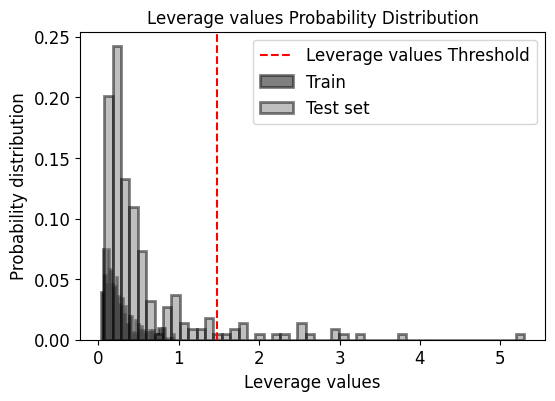

In [ ]:
# average across folds
leverage_test_list = [leverage_test[fold_].reshape(1, -1) for fold_ in train_idxs_dict.keys()]
leverage_test_mean = np.vstack(leverage_test_list).mean(axis=0).reshape(1, -1)
leverage_threshold_test = find_leverage_threshold(
    leverage_train=leverage_train_test[0],
    metric_dimensions=mean_train_embeddings[0].shape[1],
)
print(f"Leverage threshold for test set: {leverage_threshold_test:.4f}")

leverage_outliers_test, leverage_within_threshold_test = find_outliers(
    metric_test=leverage_test_mean,
    metric_threshold=leverage_threshold_test,
    metric_name="Leverage"
)
print(f"Leverage values outliers for test set: {len(leverage_outliers_test)}")
print(f"Leverage values within threshold for test set: {len(leverage_within_threshold_test)}")

plot_AD_distribution(
    metric_train=leverage_train_test[0],
    train_bin_num=50,
    metric_test=leverage_test_mean,
    test_bin_num=50,
    metric_threshold=leverage_threshold_test,
    metric_name="Leverage values",
    label_="Test set"
)S

### Mahalanobis distance

In [184]:
# mahalanobis distance
mahal_threshold_test = []

for fold_ in train_idxs_dict.keys():
    mahal_threshold_test.append(find_percentile_threshold(
        metric_train=mahal_train_test[fold_],
        percentile=95
    ))
    print(f"Mahalanobis threshold for fold {fold_ + 1}: {mahal_threshold_test[fold_]:.2f}")

print("-"*100)
mahal_threshold_test_mean = np.mean(np.array(mahal_threshold_test))
print(f"Mahalanobis threshold for test set: {mahal_threshold_test_mean:.2f}")

Mahalanobis threshold for fold 1: 15.40
Mahalanobis threshold for fold 2: 15.00
Mahalanobis threshold for fold 3: 14.79
Mahalanobis threshold for fold 4: 15.13
Mahalanobis threshold for fold 5: 15.04
Mahalanobis threshold for fold 6: 14.80
Mahalanobis threshold for fold 7: 14.89
Mahalanobis threshold for fold 8: 15.22
Mahalanobis threshold for fold 9: 15.24
Mahalanobis threshold for fold 10: 14.98
----------------------------------------------------------------------------------------------------
Mahalanobis threshold for test set: 15.05


(6147,)
Max value of Mahalanobis distance: 25.902
Mahalanobis distance data
Number of outliers:  21
Number within leverage threshold:  198
Mahalanobis distance outliers for test set: 21
Mahalanobis distance within threshold for test set: 198


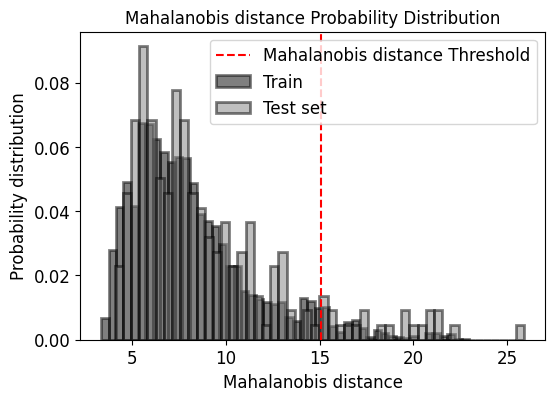

In [188]:
mahal_test_list = [mahal_test[fold_].reshape(1, -1) for fold_ in train_idxs_dict.keys()]
mahal_test_mean = np.vstack(mahal_test_list).mean(axis=0).reshape(1, -1)

mahal_train_test = np.concatenate([mahal_train_test[fold_] for fold_ in train_idxs_dict.keys()])
print(mahal_train_test.shape)

mahal_outliers_test, mahal_within_threshold_test = find_outliers(
    metric_test=mahal_test_mean,
    metric_threshold=mahal_threshold_test_mean,
    metric_name="Mahalanobis distance"
)
print(f"Mahalanobis distance outliers for test set: {len(mahal_outliers_test)}")
print(f"Mahalanobis distance within threshold for test set: {len(mahal_within_threshold_test)}")
    
plot_AD_distribution(
    metric_train=mahal_train_test,
    train_bin_num=50,
    metric_test=mahal_test_mean,
    test_bin_num=50,
    metric_threshold=mahal_threshold_test_mean,
    metric_name="Mahalanobis distance",
    label_="Test set"
)

### KNN distance

In [189]:
# knn distance
knn_threshold_test = []

for fold_ in train_idxs_dict.keys():
    knn_threshold_test.append(find_percentile_threshold(
        metric_train=knn_results_test[fold_][k_value]['train_distances'],
        percentile=95
    ))
    print(f"KNN threshold for fold {fold_ + 1}: {knn_threshold_test[fold_]:.2f}")

print("-"*100)
knn_threshold_test_mean = np.mean(np.array(knn_threshold_test))
print(f"KNN threshold for test set: {knn_threshold_test_mean:.2f}")

KNN threshold for fold 1: 17.00
KNN threshold for fold 2: 16.17
KNN threshold for fold 3: 15.72
KNN threshold for fold 4: 16.21
KNN threshold for fold 5: 16.46
KNN threshold for fold 6: 15.84
KNN threshold for fold 7: 16.18
KNN threshold for fold 8: 16.54
KNN threshold for fold 9: 16.62
KNN threshold for fold 10: 15.65
----------------------------------------------------------------------------------------------------
KNN threshold for test set: 16.24


Max value of KNN distance: 23.688
KNN distance data
Number of outliers:  13
Number within leverage threshold:  206
KNN distance outliers for test set: 13
KNN distance within threshold for test set: 206


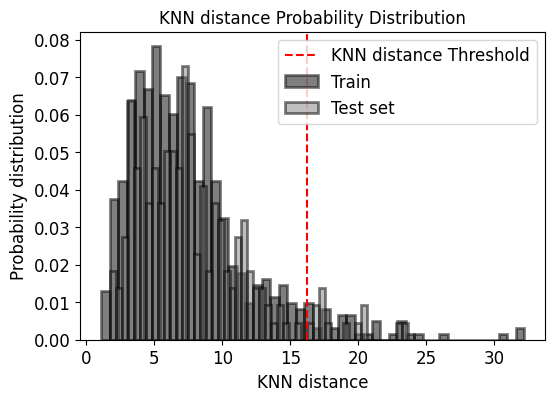

In [190]:
knn_test_list = [knn_results_test[fold_][k_value]['test_distances'].reshape(1, -1) for fold_ in train_idxs_dict.keys()]
knn_test_mean = np.vstack(knn_test_list).mean(axis=0).reshape(1, -1)

knn_outliers_test, knn_within_threshold_test = find_outliers(
    metric_test=knn_test_mean,
    metric_threshold=knn_threshold_test_mean,
    metric_name="KNN distance"
)
print(f"KNN distance outliers for test set: {len(knn_outliers_test)}")
print(f"KNN distance within threshold for test set: {len(knn_within_threshold_test)}")
    
plot_AD_distribution(
    metric_train=knn_results_test[0][k_value]['train_distances'],
    train_bin_num=50,
    metric_test=knn_test_mean,
    test_bin_num=50,
    metric_threshold=knn_threshold_test_mean,
    metric_name="KNN distance",
    label_="Test set"
)

### PCA T2 statistics

In [191]:
# PCA T2 statistics
pca_t2_threshold_test = []

for fold_ in train_idxs_dict.keys():
    pca_t2_threshold_test.append(find_percentile_threshold(
        metric_train=pca_results_test[fold_][2],
        percentile=95
    ))
    print(f"PCA T² threshold for fold {fold_ + 1}: {pca_t2_threshold_test[fold_]:.2f}")

print("-"*100)
pca_t2_threshold_test_mean = np.mean(np.array(pca_t2_threshold_test))
print(f"PCA T² threshold for test set: {pca_t2_threshold_test_mean:.2f}")

PCA T² threshold for fold 1: 2.46
PCA T² threshold for fold 2: 2.51
PCA T² threshold for fold 3: 2.46
PCA T² threshold for fold 4: 2.52
PCA T² threshold for fold 5: 2.48
PCA T² threshold for fold 6: 2.48
PCA T² threshold for fold 7: 2.46
PCA T² threshold for fold 8: 2.43
PCA T² threshold for fold 9: 2.52
PCA T² threshold for fold 10: 2.48
----------------------------------------------------------------------------------------------------
PCA T² threshold for test set: 2.48


Max value of PCA T²: 3.311
PCA T² data
Number of outliers:  14
Number within leverage threshold:  205
PCA T2 outliers for test set: 14
PCA T2 within threshold for test set: 205


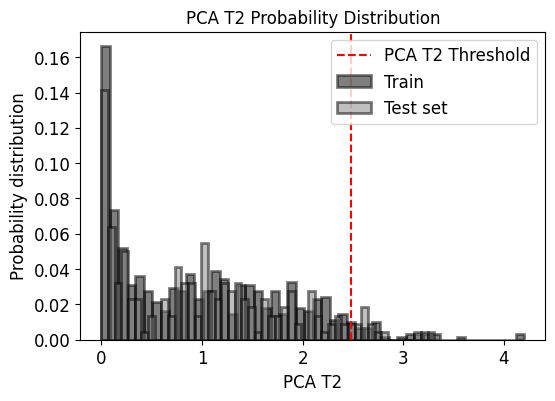

In [193]:
pca_t2_test_list = [pca_results_test[fold_][3].reshape(1, -1) for fold_ in train_idxs_dict.keys()]
pca_t2_test_mean = np.vstack(pca_t2_test_list).mean(axis=0).reshape(1, -1)

pca_t2_outliers_test, pca_t2_within_threshold_test = find_outliers(
    metric_test=pca_t2_test_mean,
    metric_threshold=pca_t2_threshold_test_mean,
    metric_name="PCA T²"
)
print(f"PCA T2 outliers for test set: {len(pca_t2_outliers_test)}")
print(f"PCA T2 within threshold for test set: {len(pca_t2_within_threshold_test)}")
    
plot_AD_distribution(
    metric_train=pca_results_test[0][2],
    train_bin_num=50,   
    metric_test=pca_t2_test_mean,
    test_bin_num=50,
    metric_threshold=pca_t2_threshold_test_mean,
    metric_name="PCA T2",
    label_="Test set"
)

## Saving results

In [202]:
print("test_smi shape",test_smis.shape)
print("test_ys shape",test_ys.shape)
print("leverage_test_mean shape",leverage_test_mean.flatten().shape)
print("mahal_test_mean shape",mahal_test_mean.flatten().shape)
print("knn_test_mean shape",knn_test_mean.flatten().shape)
print("pca_t2_test_mean shape",pca_t2_test_mean.flatten().shape)

test_smi shape (219,)
test_ys shape (219,)
leverage_test_mean shape (219,)
mahal_test_mean shape (219,)
knn_test_mean shape (219,)
pca_t2_test_mean shape (219,)


In [204]:
ad_metrics_test_df = pd.DataFrame(
    {
        'sample_index': np.arange(len(test_smis)),
        'SMILES': test_smis,
        'logTg': test_ys,
        'leverage': leverage_test_mean.flatten(),
        'leverage_threshold': leverage_threshold_test,
        'mahalanobis': mahal_test_mean.flatten(),
        'mahalanobis_threshold': mahal_threshold_test_mean,
        f'knn_{k_value}': knn_test_mean.flatten(),
        f'knn_{k_value}_threshold': knn_threshold_test_mean,
        'pca_t2': pca_t2_test_mean.flatten(),
        'pca_t2_threshold': pca_t2_threshold_test_mean,
    }
)

In [207]:
ad_metrics_test_df['leverage_outlier'] = (
    ad_metrics_test_df['leverage'] > ad_metrics_test_df['leverage_threshold']
)

ad_metrics_test_df['mahalanobis_outlier'] = (
    ad_metrics_test_df['mahalanobis'] > ad_metrics_test_df['mahalanobis_threshold']
)

ad_metrics_test_df[f'knn_{k_value}_outlier'] = (
    ad_metrics_test_df[f'knn_{k_value}'] > ad_metrics_test_df[f'knn_{k_value}_threshold']
)

ad_metrics_test_df['pca_t2_outlier'] = (
    ad_metrics_test_df['pca_t2'] > ad_metrics_test_df['pca_t2_threshold']
)

# Count how many methods flag each sample as outlier
ad_metrics_test_df['outlier_flag_count'] = (
    ad_metrics_test_df['leverage_outlier'].astype(int) +
    ad_metrics_test_df['mahalanobis_outlier'].astype(int) +
    ad_metrics_test_df[f'knn_{k_value}_outlier'].astype(int) +
    ad_metrics_test_df['pca_t2_outlier'].astype(int)
)

# Consensus outliers: flagged by >=2 methods
ad_metrics_test_df['consensus_outlier'] = ad_metrics_test_df['outlier_flag_count'] >= 2

# High confidence outliers: flagged by >=3 methods
ad_metrics_test_df['high_confidence_outlier'] = ad_metrics_test_df['outlier_flag_count'] >= 3

print("Outlier identification columns added!")
print(f"\nOutlier summary:")
print(f"  Leverage outliers: {ad_metrics_test_df['leverage_outlier'].sum()}")
print(f"  Mahalanobis outliers: {ad_metrics_test_df['mahalanobis_outlier'].sum()}")
print(f"  kNN outliers: {ad_metrics_test_df[f'knn_{k_value}_outlier'].sum()}")
print(f"  PCA T² outliers: {ad_metrics_test_df['pca_t2_outlier'].sum()}")
print(f"  Consensus outliers (≥2 methods): {ad_metrics_test_df['consensus_outlier'].sum()}")
print(f"  High confidence outliers (≥3 methods): {ad_metrics_test_df['high_confidence_outlier'].sum()}")

print(f"\nOutlier flag count distribution:")
print(ad_metrics_test_df['outlier_flag_count'].value_counts().sort_index())

Outlier identification columns added!

Outlier summary:
  Leverage outliers: 19
  Mahalanobis outliers: 21
  kNN outliers: 13
  PCA T² outliers: 14
  Consensus outliers (≥2 methods): 20
  High confidence outliers (≥3 methods): 12

Outlier flag count distribution:
outlier_flag_count
0    185
1     14
2      8
3     11
4      1
Name: count, dtype: int64


In [255]:
# Save comprehensive validation AD metrics
ad_metrics_test_df.to_csv(results_dir / "ad_metrics_test_set.csv", index=False)
print(f"Saved validation AD metrics to: {results_dir / 'ad_metrics_test_set.csv'}")

Saved validation AD metrics to: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/data/processed/applicability_domain/ad_metrics_test_set.csv


# Discuss extreme outliers

## Leverage values

In [211]:
ad_metrics_val_df[
    ad_metrics_val_df['leverage_outlier']
]['leverage'].describe()

count    97.000000
mean      3.125379
std       2.292559
min       1.477579
25%       1.887937
50%       2.352951
75%       3.707023
max      16.419773
Name: leverage, dtype: float64

In [217]:
ad_metrics_val_df[
    ad_metrics_val_df['leverage'] > 10
][['SMILES','logTg', 'leverage']].merge(
    df_train[['SMILES_clean','name']], left_on='SMILES', right_on='SMILES_clean', how='left'
)

,SMILES,logTg,leverage,SMILES_clean,name
0,C1CS1,2.6956,10.986921,C1CS1,ethylene sulfide
1,C1=CC=C=CC=1,2.9091,16.419773,C1=CC=C=CC=1,p-phenylene
2,C=C,2.2900,12.283908,C=C,ethylene


In [226]:
ad_metrics_test_df[
    ad_metrics_test_df['leverage'] > 3
][['SMILES','logTg', 'leverage']].merge(
    df_test[['SMILES_clean','name', 'SMILES_raw']], left_on='SMILES', right_on='SMILES_clean', how='left'
)

,SMILES,logTg,leverage,SMILES_clean,name,SMILES_raw
0,C1CO1,2.3163,3.740213,C1CO1,Ethylene oxide,C1CO1
1,CCO[C@H](C)CC,2.4031,3.275496,CCO[C@H](C)CC,Poly((2R)?2?ethoxybutane),CCO[C@H](C)CC
2,CC(CO)(CCl)CCl,2.4232,5.294094,CC(CO)(CCl)CCl,"oxy-2,2-dichloromethyl trimethylene",CC(CO)(CCl)CCl
3,C=CC(Cl)C(=O)[O-],2.4829,3.007907,C=CC(Cl)C(=O)[O-],vinylchloroacetate,C=CC(C(=O)[O-])Cl


## Mahalanobis distance

In [229]:
## Mahalanobis distance
ad_metrics_val_df[
    ad_metrics_val_df['mahalanobis_outlier']
]['mahalanobis'].describe()

count    76.000000
mean     19.275564
std       4.790281
min      15.082901
25%      16.324247
50%      17.878465
75%      20.347386
max      39.262126
Name: mahalanobis, dtype: float64

In [235]:
ad_metrics_val_df[
    ad_metrics_val_df['mahalanobis'] > 25
][['SMILES','logTg', 'mahalanobis']].merge(
    df_train[['SMILES_clean','name', 'SMILES_raw']], left_on='SMILES', right_on='SMILES_clean', how='left'
)

,SMILES,logTg,mahalanobis,SMILES_clean,name,SMILES_raw
0,C1CS1,2.6956,38.948860,C1CS1,ethylene sulfide,C1CS1
1,O=[N+]([O-])OCC1OC(OC2C(CO[N+](=O)[O-])OC(O[N+...,2.5134,32.221771,O=[N+]([O-])OCC1OC(OC2C(CO[N+](=O)[O-])OC(O[N+...,Cellulose nitrate,C(C1C(C(C(C(O1)OC2C(OC(C(C2O[N+](=O)\n[O-])O[N...
2,C=CSC,2.4346,27.628920,C=CSC,vinyl methyl sulfide,CSC=C
3,C1=CC=C=CC=1,2.9091,39.262126,C1=CC=C=CC=1,p-phenylene,C1=C=CC=C=C1
4,C[SiH](C)O,2.1703,27.464049,C[SiH](C)O,dimethylsiloxane,C[SiH](C)O
5,OCCCO,2.6722,26.593904,OCCCO,trimethylene glycol,C(CO)CO
6,C=C,2.2900,28.353302,C=C,ethylene,C=C
7,O=C1COC(=O)CO1,2.7673,25.473960,O=C1COC(=O)CO1,Polyglycolid,O=C1COC(=O)CO1


In [236]:
ad_metrics_test_df[
    ad_metrics_test_df['mahalanobis'] > 20
][['SMILES','logTg', 'mahalanobis']].merge(
    df_test[['SMILES_clean','name', 'SMILES_raw']], left_on='SMILES', right_on='SMILES_clean', how='left'
)

,SMILES,logTg,mahalanobis,SMILES_clean,name,SMILES_raw
0,C=CSCC,2.7317,21.257075,C=CSCC,ethyl vinyl thioether,CCSC=C
1,O=C1CC(=O)OCCO1,2.3877,20.204206,O=C1CC(=O)OCCO1,Ethylene malonate,C1COC(=O)CC(=O)O1
2,C1CO1,2.3163,21.001772,C1CO1,Ethylene oxide,C1CO1
3,C1COC1,2.2904,25.902047,C1COC1,Trimethylene oxide,C1COC1
4,C=C,2.1703,21.133292,C=C,ethylene,C=C
5,CC1CS1,2.3541,20.826321,CC1CS1,propylene sulfide,CC1CS1
6,CC(CO)(CCl)CCl,2.4232,22.087571,CC(CO)(CCl)CCl,"oxy-2,2-dichloromethyl trimethylene",CC(CO)(CCl)CCl
7,C=CC(Cl)C(=O)[O-],2.4829,20.246364,C=CC(Cl)C(=O)[O-],vinylchloroacetate,C=CC(C(=O)[O-])Cl


## KNN distance

In [241]:
## KNN distance
ad_metrics_val_df[
    ad_metrics_val_df[f'knn_{k_value}_outlier']
][f'knn_{k_value}'].describe()

count    32.000000
mean     19.704941
std       3.152735
min      16.218782
25%      17.454312
50%      18.780636
75%      21.190133
max      27.786142
Name: knn_5, dtype: float64

In [243]:
ad_metrics_val_df[
    ad_metrics_val_df[f'knn_{k_value}'] > 25
]

,sample_index,fold,SMILES,logTg,leverage,leverage_threshold,mahalanobis,mahalanobis_threshold,knn_5,knn_5_threshold,pca_t2,pca_t2_threshold,leverage_outlier,mahalanobis_outlier,knn_5_outlier,pca_t2_outlier,outlier_flag_count,consensus_outlier,high_confidence_outlier
142,142,2,O=[N+]([O-])OCC1OC(OC2C(CO[N+](=O)[O-])OC(O[N+...,2.5134,8.610624,1.470684,32.221771,14.791809,25.937220,15.716342,0.165386,2.455765,True,True,True,False,3,True,True
156,156,2,C=CSC,2.4346,4.853152,1.470684,27.628920,14.791809,27.786142,15.716342,0.750326,2.455765,True,True,True,False,3,True,True
212,212,3,C1=CC=C=CC=1,2.9091,16.419773,1.468293,39.262126,15.128120,25.583470,16.211460,0.463914,2.516010,True,True,True,False,3,True,True
215,215,3,C[SiH](C)O,2.1703,6.020564,1.468293,27.464049,15.128120,25.714687,16.211460,3.347929,2.516010,True,True,True,True,4,True,True


In [245]:
ad_metrics_test_df[
    ad_metrics_test_df[f'knn_{k_value}'] > 20
][['SMILES','logTg', f'knn_{k_value}']].merge(
    df_test[['SMILES_clean','name', 'SMILES_raw']], left_on='SMILES', right_on='SMILES_clean', how='left'
)

,SMILES,logTg,knn_5,SMILES_clean,name,SMILES_raw
0,C=CSCC,2.7317,22.926713,C=CSCC,ethyl vinyl thioether,CCSC=C
1,C1COC1,2.2904,23.688126,C1COC1,Trimethylene oxide,C1COC1
2,C=C,2.1703,20.363855,C=C,ethylene,C=C
3,CC1CS1,2.3541,20.427628,CC1CS1,propylene sulfide,CC1CS1


## PCA T2 statistics

In [246]:
## PCA T2 statistics
ad_metrics_val_df[
    ad_metrics_val_df['pca_t2_outlier']
]['pca_t2'].describe()

count    39.000000
mean      2.956552
std       0.451253
min       2.470191
25%       2.649545
50%       2.807528
75%       3.221234
max       4.392820
Name: pca_t2, dtype: float64

In [250]:
ad_metrics_val_df[
    ad_metrics_val_df['pca_t2'] > 3.5
][['SMILES','logTg', 'leverage']].merge(
    df_train[['SMILES_clean','name']], left_on='SMILES', right_on='SMILES_clean', how='left'
)

,SMILES,logTg,leverage,SMILES_clean,name
0,c1ccc(-c2cnc3cc4nc(-c5ccccc5)c(-c5ccccc5)nc4cc...,2.8048,0.544252,c1ccc(-c2cnc3cc4nc(-c5ccccc5)c(-c5ccccc5)nc4cc...,"2,3,7-triphenylpyrazino[2,3-g]quinoxaline"
1,C=CC(=O)OCC(F)(F)C(F)(F)OC(F)(F)C(F)(F)F,2.3502,2.125337,C=CC(=O)OCC(F)(F)C(F)(F)OC(F)(F)C(F)(F)F,"1H,1H-nonafluoro-4-oxahexyl acrylate"
2,C=CC(=O)OCCOC(F)(F)C(F)F,2.3997,1.657118,C=CC(=O)OCCOC(F)(F)C(F)F,"4,4,5,5-tetrafluoro-3-oxapentyl acrylate"
3,O=C1c2ccccc2C(c2ccccc2)(c2ccc(-c3cc(-c4ccccc4)...,2.8215,0.418058,O=C1c2ccccc2C(c2ccccc2)(c2ccc(-c3cc(-c4ccccc4)...,"10-(4-{6-[10-oxo-9-(4-phenylquinolin-6-yl)-9,1..."


In [253]:
ad_metrics_test_df[
    ad_metrics_test_df[f'pca_t2'] > 3
][['SMILES','logTg', f'pca_t2']].merge(
    df_test[['SMILES_clean','name', 'SMILES_raw']], left_on='SMILES', right_on='SMILES_clean', how='left'
)

,SMILES,logTg,pca_t2,SMILES_clean,name,SMILES_raw
0,C=C,2.1703,3.168890,C=C,ethylene,C=C
1,CCO,2.5539,3.310951,CCO,ethanol,CCO
2,c1ccc(-c2ccnc3ccc(C4(c5ccc6nc(-c7ccc(C8(c9cccc...,2.8215,3.196863,c1ccc(-c2ccnc3ccc(C4(c5ccc6nc(-c7ccc(C8(c9cccc...,4-phenyl-2-[4-(9-phenyl-9H-fluoren-9-yl)phenyl...,c1ccc(cc1)c1c2cc(ccc2nc(c1)c1ccc(cc1)C1(c2c\nc...
